# Microproyecto 2: clasificación de textos según los ODS

**Curso:** Machine Learning No Supervisado - Maestría en Inteligencia Artificial
**Autores:** Benjamin Ricardo Collante Juvinao, Sara Gallego Villada
**Entrega:** semana 7

Este notebook desarrolla, de punta a punta, una solución de NLP + ML para clasificar automáticamente
textos en español según los Objetivos de Desarrollo Sostenible (ODS). Cada decisión metodológica
está justificada en una celda Markdown junto al código que la implementa, y todas las celdas
quedan ejecutadas con sus salidas visibles.

| Actividad del enunciado | Sección |
|---|---|
| 1. Preparación de textos: bolsa de palabras + TF-IDF dentro de un pipeline | 6 |
| 2. LSA con `TruncatedSVD` (10-20 componentes), ≥ 5 tópicos interpretados frente a los ODS | 7 |
| 3. Modelo de clasificación con reducción de dimensionalidad y búsqueda de hiperparámetros | 8-9 |
| 4. Evaluación con textos no usados en el aprendizaje (≥ 4 ejemplos) | 10-11 |
| Bono: aplicación Streamlit con el mismo pipeline | 13 y `app/streamlit_app.py` |

## 1. Contexto, problema y objetivo

La Agenda 2030 de la ONU define **17 Objetivos de Desarrollo Sostenible (ODS)**. Entidades como el
UNFPA analizan grandes volúmenes de información textual (planes de desarrollo, aportes de
participación ciudadana, reportes) y necesitan relacionar cada texto con el ODS al que contribuye.
Hoy esa tarea la hacen expertos manualmente, lo que es lento y costoso.

**Problema de ML.** Es un problema de **clasificación multiclase de texto**: dada una cadena en
español, predecir una única etiqueta ODS. Es un problema *supervisado*, pero el curso pide
resolverlo apoyándose en técnicas *no supervisadas* de representación: bolsa de palabras con
ponderación TF-IDF y **análisis semántico latente (LSA)** mediante SVD truncado, que reduce la
dimensionalidad del espacio de términos y a la vez descubre "tópicos" interpretables.

**Alcance real del dataset.** Los datos provienen del *OSDG Community Dataset* (2023), traducidos al
español con DeepL y aumentados con la API de ChatGPT. Como se verificará en la sección 3, el
archivo entregado contiene **únicamente las etiquetas ODS 1 a 16**; el ODS 17 (*Alianzas para
lograr los objetivos*) no tiene ejemplos, por lo que el modelo **no puede predecirlo** y toda
afirmación sobre "los 17 ODS" debe leerse como "los 16 ODS presentes en los datos".

**Objetivos del notebook.**

1. Construir un pipeline reproducible de preparación de textos (limpieza -> BOW -> TF-IDF).
2. Obtener un modelo de tópicos LSA sobre la matriz TF-IDF e interpretar al menos cinco tópicos.
3. Entrenar y seleccionar, con búsqueda de hiperparámetros y validación cruzada, un clasificador
   que use reducción de dimensionalidad, justificando algoritmo y métricas.
4. Evaluar el modelo final **una sola vez** sobre un conjunto de test aislado y mostrar la
   predicción de al menos cuatro textos de ese conjunto.
5. (Bono) Exponer el mismo pipeline en una app Streamlit.

## 2. Importación de librerías y reproducibilidad

Se importan solo las librerías utilizadas. El notebook es **autocontenido**: todas las funciones
auxiliares se definen en la sección donde se usan (limpieza y TF-IDF en la 6, LSA en la 7, pipeline
y búsqueda en la 8, métricas en la 10). La app Streamlit (`streamlit_app.py`) reutiliza el
`Pipeline` serializado en la sección 13, que ya incluye la limpieza como `preprocessor` del
TF-IDF; así se cumple la condición del bono de "procesar el texto utilizando el mismo pipeline
construido en el proyecto".

Se fija `RANDOM_STATE = 42` y se usa en el split, en la validación cruzada, en el SVD
(`algorithm="randomized"`) y en los clasificadores, de modo que el notebook sea reproducible.

In [1]:
import re
import sys
import time
import unicodedata
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)

# Catálogo de los 17 ODS (el 17 no aparece en los datos, pero se incluye para que las etiquetas sean completas)
ODS_NAMES = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educación de calidad",
    5: "Igualdad de género",
    6: "Agua limpia y saneamiento",
    7: "Energía asequible y no contaminante",
    8: "Trabajo decente y crecimiento económico",
    9: "Industria, innovación e infraestructura",
    10: "Reducción de las desigualdades",
    11: "Ciudades y comunidades sostenibles",
    12: "Producción y consumo responsables",
    13: "Acción por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones sólidas",
    17: "Alianzas para lograr los objetivos",
}
TEXT_COL, LABEL_COL = "textos", "ODS"

# Rutas: el notebook funciona tanto dentro del repositorio (notebooks/ o raíz) como suelto en una carpeta
# junto al Excel. Las salidas (figuras, tablas y modelo) se crean junto al notebook.
CWD = Path.cwd().resolve()
CANDIDATOS_DATA = [
    CWD / "data" / "Datos_textosODS.xlsx",
    CWD.parent / "data" / "Datos_textosODS.xlsx",
    CWD / "Datos_textosODS.xlsx",
    CWD / "textos_ods.xlsx",
]
DATA_PATH = next((p for p in CANDIDATOS_DATA if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró el dataset; coloque Datos_textosODS.xlsx junto al notebook o en data/.")

ROOT = DATA_PATH.parent.parent if DATA_PATH.parent.name == "data" else CWD
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
MODEL_DIR = ROOT / "models"
for d in (FIG_DIR, TAB_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Dataset :", DATA_PATH)
print("Salidas :", ROOT)
print("Python  :", sys.version.split()[0])
import sklearn; print("scikit-learn:", sklearn.__version__)

Dataset : C:\Maestria Saris\MLNS\microproyecto-2-ods\data\Datos_textosODS.xlsx
Salidas : C:\Maestria Saris\MLNS\microproyecto-2-ods
Python  : 3.14.6
scikit-learn: 1.9.1


## 3. Carga y auditoría del conjunto de datos

Antes de modelar se comprueba la estructura del archivo: dimensiones, tipos, valores nulos,
duplicados exactos y el conjunto de etiquetas disponibles. Esta auditoría determina decisiones
posteriores (por ejemplo, si hay que deduplicar antes del split para evitar fuga de información,
o qué clases puede realmente aprender el modelo).

In [2]:
def load_dataset(path):
    '''Carga el Excel del proyecto y valida su estructura mínima.'''
    df = pd.read_excel(path)
    faltan = {TEXT_COL, LABEL_COL} - set(df.columns)
    if faltan:
        raise ValueError(f"Faltan columnas en el dataset: {sorted(faltan)}")
    df[TEXT_COL] = df[TEXT_COL].astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df


df = load_dataset(DATA_PATH)

print("Dimensiones:", df.shape)
print("\nTipos de dato:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isna().sum())
print("\nDuplicados exactos (fila completa):", int(df.duplicated().sum()))
print("Textos duplicados (solo columna de texto):", int(df[TEXT_COL].duplicated().sum()))
print("Textos vacíos o solo espacios:", int((df[TEXT_COL].str.strip() == "").sum()))

etiquetas = sorted(df[LABEL_COL].unique())
print("\nEtiquetas presentes:", etiquetas)
print("Etiquetas del 1 al 17 ausentes:", sorted(set(range(1, 18)) - set(etiquetas)))
df.head(3)

Dimensiones: (9656, 2)

Tipos de dato:
textos    object
ODS        int64
dtype: object

Valores nulos por columna:
textos    0
ODS       0
dtype: int64

Duplicados exactos (fila completa): 0
Textos duplicados (solo columna de texto): 0
Textos vacíos o solo espacios: 0

Etiquetas presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Etiquetas del 1 al 17 ausentes: [17]


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas e...",4
1,No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del agua y a peticiones de compensación cuan...,6
2,"Como resultado, un mayor y mejorado acceso al agua puede afectar aún más la capacidad de adaptación y resiliencia de las comunidades al cambio climático. Pa...",13


**Interpretación.** El dataset tiene 9 656 textos con dos columnas (`textos`, `ODS`), sin valores
nulos, sin filas duplicadas y sin textos vacíos, así que no hace falta limpieza estructural ni
deduplicación previa al split. Están presentes las etiquetas **1 a 16**; el **ODS 17 no aparece**,
luego el modelo se entrenará y evaluará sobre 16 clases y no se debe afirmar que cubre los 17 ODS.

## 4. Análisis exploratorio

Se analizan dos aspectos que condicionan directamente el diseño del modelo:

1. **Distribución de clases**: si hay desbalance, la métrica de selección debe ser robusta a él
   (F1 macro en lugar de accuracy) y conviene ponderar las clases.
2. **Longitud de los textos**: determina si el esquema bolsa de palabras es razonable (textos muy
   cortos dan vectores demasiado dispersos) y si conviene `sublinear_tf`.

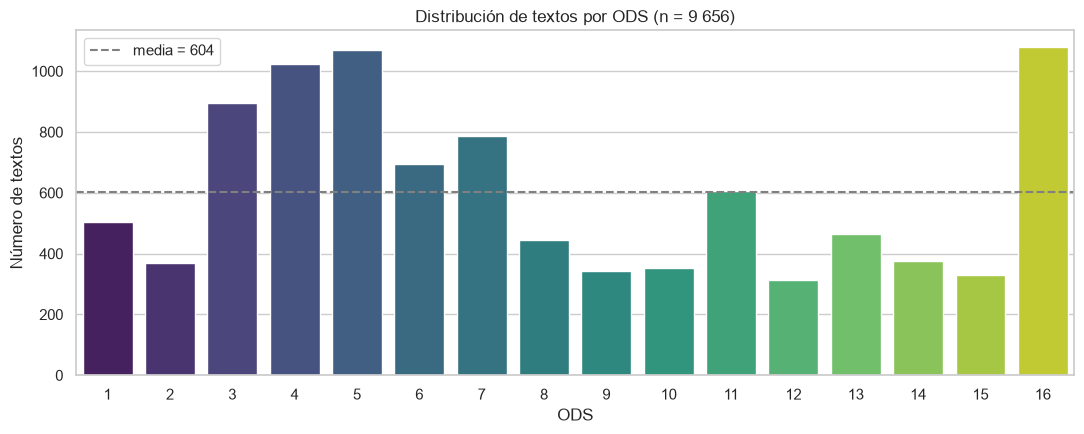

Clase más grande: ODS 16 (1080 textos)
Clase más pequeña: ODS 12 (312 textos)
Ratio máx/mín: 3.46


,nombre,n_textos,proporcion
ODS,,,
1,Fin de la pobreza,505,0.0523
2,Hambre cero,369,0.0382
3,Salud y bienestar,894,0.0926
4,Educación de calidad,1025,0.1062
5,Igualdad de género,1070,0.1108
6,Agua limpia y saneamiento,695,0.0720
7,Energía asequible y no contaminante,787,0.0815
8,Trabajo decente y crecimiento económico,446,0.0462
9,"Industria, innovación e infraestructura",343,0.0355


In [3]:
conteo = (
    df[LABEL_COL].value_counts().sort_index().rename("n_textos").to_frame()
)
conteo["nombre"] = conteo.index.map(ODS_NAMES)
conteo["proporcion"] = (conteo["n_textos"] / len(df)).round(4)
conteo = conteo[["nombre", "n_textos", "proporcion"]]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=conteo.index.astype(str), y=conteo["n_textos"], hue=conteo.index.astype(str), palette="viridis", legend=False, ax=ax)
ax.axhline(conteo["n_textos"].mean(), ls="--", c="gray", label=f"media = {conteo['n_textos'].mean():.0f}")
ax.set_xlabel("ODS")
ax.set_ylabel("Número de textos")
ax.set_title("Distribución de textos por ODS (n = 9 656)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "01_distribucion_ods.png", dpi=120)
plt.show()

print(f"Clase más grande: ODS {conteo['n_textos'].idxmax()} ({conteo['n_textos'].max()} textos)")
print(f"Clase más pequeña: ODS {conteo['n_textos'].idxmin()} ({conteo['n_textos'].min()} textos)")
print(f"Ratio máx/mín: {conteo['n_textos'].max() / conteo['n_textos'].min():.2f}")
conteo

**Interpretación.** Las clases están **moderadamente desbalanceadas**: ODS 16 (1 080), ODS 5
(1 070) y ODS 4 (1 025) tienen más de tres veces los textos de ODS 12 (312), ODS 15 (330) y
ODS 9 (343). Un clasificador que optimice solo la exactitud podría descuidar las clases pequeñas.
Por eso:

- la **métrica principal será F1 macro** (promedia el F1 de cada clase con igual peso, sin importar
  su tamaño), acompañada de accuracy, precision/recall macro y F1 ponderado;
- el **split será estratificado** para conservar estas proporciones en train y test;
- los clasificadores usarán `class_weight="balanced"`.

               count   mean    std    min    25%    50%    75%     max
n_caracteres  9656.0  709.0  238.9  143.0  522.0  669.0  864.0  1977.0
n_palabras    9656.0  111.0   37.1   24.0   82.0  105.0  135.0   268.0


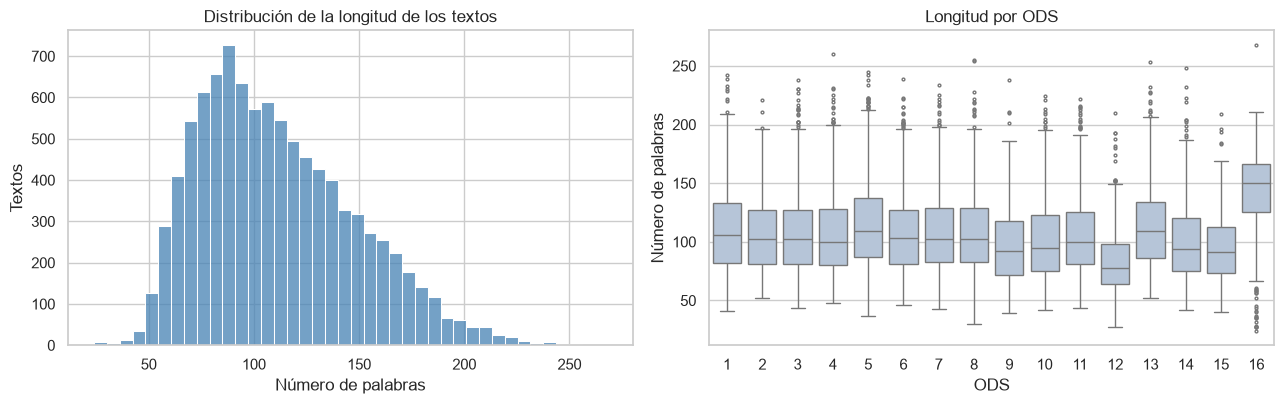

In [4]:
df["n_caracteres"] = df[TEXT_COL].str.len()
df["n_palabras"] = df[TEXT_COL].str.split().str.len()

print(df[["n_caracteres", "n_palabras"]].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(df["n_palabras"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de la longitud de los textos")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Textos")
orden = sorted(df[LABEL_COL].unique())
sns.boxplot(data=df, x=LABEL_COL, y="n_palabras", order=orden, ax=axes[1], color="lightsteelblue", fliersize=2)
axes[1].set_title("Longitud por ODS")
axes[1].set_xlabel("ODS")
axes[1].set_ylabel("Número de palabras")
plt.tight_layout()
fig.savefig(FIG_DIR / "02_longitud_textos.png", dpi=120)
plt.show()

**Interpretación.** Los textos son párrafos de tamaño medio (mediana ≈ 105 palabras, entre 24 y
268), con longitud similar entre ODS. Esto es adecuado para bolsa de palabras: hay suficiente
vocabulario por documento para que TF-IDF sea informativo, y la longitud no es una señal que
discrimine clases (no hay que normalizarla explícitamente; la normalización L2 de TF-IDF ya elimina
el efecto de la longitud).

In [5]:
# Ejemplos representativos: un texto de tres ODS distintos
for ods in (4, 6, 16):
    ejemplo = df.loc[df[LABEL_COL] == ods, TEXT_COL].iloc[0]
    print(f"── ODS {ods} · {ODS_NAMES[ods]} ──")
    print(ejemplo[:400], "…\n")

── ODS 4 · Educación de calidad ──
"Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formación de docentes, se consideran extensiones de los acuerdos establecidos por los gobiernos. Este marco de comprensión se ha vuelto cada vez más inadecuado. …

── ODS 6 · Agua limpia y saneamiento ──
No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del agua y a peticiones de compensación cuando haya que reducir los derechos para evitar comprometer la calidad del agua y otros resultados medioambientales. Por ejemplo, es fundamental evitar cualquier escasez en la disponibilidad de agua para la refrigeración de centrales nucleares, ya …

── ODS 16 · Paz, justicia e instituciones sólidas ──
Con el Congreso firmemente en control de la jurisdicción, los recursos y la estructura de los tribunales federal

**Interpretación.** Los ejemplos muestran textos formales de tipo informe/artículo, traducidos de
forma homogénea, con vocabulario técnico muy ligado al ODS (escolarización/docentes -> ODS 4;
derechos de agua/calidad del agua -> ODS 6). Esto anticipa que los términos por sí solos (sin
lematizar) ya son fuertemente discriminantes.

## 5. Separación de entrenamiento y prueba

La división se realiza **antes** de ajustar cualquier transformación aprendida (TF-IDF, SVD,
clasificador). Si el vocabulario o el IDF se calcularan con todo el dataset, información del test
se filtraría al entrenamiento y las métricas finales quedarían optimistas.

Decisiones:

- `test_size=0.2` -> 1 932 textos de test, suficientes para estimar métricas por clase con
  soporte mínimo de ~62 textos (ODS 12).
- `stratify=y` -> cada ODS mantiene su proporción en ambos conjuntos.
- `random_state=42` -> reproducibilidad.

El conjunto de test **solo se usará en la sección 10** (evaluación final) y en la 11 (evidencia
de predicciones). Toda selección de modelo e hiperparámetros se hará con validación cruzada dentro
del conjunto de entrenamiento.

In [6]:
X = df[TEXT_COL]
y = df[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {len(X_train)} textos  |  Test: {len(X_test)} textos")
dist = pd.DataFrame(
    {
        "train": y_train.value_counts(normalize=True).sort_index().round(4),
        "test": y_test.value_counts(normalize=True).sort_index().round(4),
        "n_test": y_test.value_counts().sort_index(),
    }
)
dist.index.name = "ODS"
dist.T

Entrenamiento: 7724 textos  |  Test: 1932 textos


ODS,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
train,0.0523,0.0382,0.0926,0.1062,0.1108,0.0720,0.0814,0.0462,0.0355,0.0365,0.0628,0.0324,0.0480,0.0391,0.0342,0.1119
test,0.0523,0.0383,0.0927,0.1061,0.1108,0.0719,0.0818,0.0461,0.0357,0.0362,0.0631,0.0321,0.0481,0.0388,0.0342,0.1118
n_test,101.0000,74.0000,179.0000,205.0000,214.0000,139.0000,158.0000,89.0000,69.0000,70.0000,122.0000,62.0000,93.0000,75.0000,66.0000,216.0000


**Interpretación.** Las proporciones por clase son idénticas (hasta el cuarto decimal) en train y
test, y la clase minoritaria conserva 62 textos de test, suficiente para que precision/recall por
clase sean estables. A partir de aquí `X_test`/`y_test` no se tocan hasta la sección 10.

## 6. Preparación de textos y TF-IDF (Actividad 1)

### Decisiones de preprocesamiento y su justificación

La limpieza está implementada en la función `clean_text` (celda siguiente) y se inyecta como
`preprocessor` del `TfidfVectorizer`, de modo que **forma parte del pipeline** (se aplica igual en
entrenamiento, validación cruzada, test y en la app):

| Paso | Decisión | Por qué |
|---|---|---|
| Minúsculas | Sí | "Agua" y "agua" son el mismo término. |
| URLs | Se eliminan | No aportan significado y generan tokens únicos. |
| Normalización Unicode NFC | Sí | Evita que una misma vocal acentuada tenga dos codificaciones. |
| Dígitos y puntuación | Se eliminan | Los números (años, porcentajes) no distinguen ODS y aumentan el vocabulario. |
| Tildes y ñ | **Se conservan** | Quitarlas fusionaría palabras distintas (*término/termino*) y afea los tópicos. |
| Stopwords | NLTK español + ~25 términos de dominio | Palabras funcionales y verbos genéricos ("puede", "además") aparecen en todos los ODS y solo añaden ruido. |
| Stemming / lematización | **No** | El corpus es formal y traducido de forma consistente; las palabras completas mantienen los tópicos LSA y los coeficientes del clasificador directamente legibles. Se prioriza interpretabilidad, criterio explícito del enunciado. |
| Tokens | Solo palabras de ≥ 3 letras | Elimina residuos de una o dos letras tras la limpieza. |

### Parámetros del `TfidfVectorizer`

| Parámetro | Valor | Por qué |
|---|---|---|
| `ngram_range` | (1, 2) | Los bigramas capturan expresiones fijas muy discriminantes: *cambio climático*, *salud mental*, *aguas residuales*, *derechos humanos*. |
| `min_df` | 3 | Un término en menos de 3 documentos es casi seguro ruido (nombres propios, errores de traducción) y no generaliza. |
| `max_df` | 0.90 | Elimina términos presentes en > 90 % de los textos (stopwords residuales). |
| `sublinear_tf` | True | Usa 1 + log(tf): que una palabra se repita 10 veces no la hace 10 veces más importante. |
| `max_features` | 30 000 | Cota superior del vocabulario para acotar memoria y tiempo del grid search sin perder términos relevantes. |
| `norm` | L2 (por defecto) | Cada documento queda con norma 1 -> independiente de su longitud. |

La ponderación **TF-IDF** (frecuencia del término × inverso de la frecuencia documental) da más
peso a palabras frecuentes en un documento pero raras en el corpus - exactamente las que
caracterizan a un ODS - y menos a las que aparecen en todas partes.

In [7]:
_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_NON_LETTER_RE = re.compile(r"[^a-záéíóúüñ\s]")
_MULTISPACE_RE = re.compile(r"\s+")


def clean_text(text):
    '''Normaliza un texto en español para el esquema bolsa de palabras.

    1. minúsculas; 2. elimina URLs; 3. normaliza Unicode (NFC); 4. elimina dígitos y puntuación
    conservando tildes y ñ; 5. colapsa espacios. Sin stemming ni lematización (interpretabilidad).
    '''
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = _URL_RE.sub(" ", text)
    text = unicodedata.normalize("NFC", text)
    text = _NON_LETTER_RE.sub(" ", text)
    text = _MULTISPACE_RE.sub(" ", text).strip()
    return text


# Términos muy frecuentes en el corpus que no discriminan entre ODS; se suman a las stopwords de NLTK
DOMAIN_STOPWORDS = (
    "así", "además", "ejemplo", "según", "través", "puede", "pueden",
    "ser", "hacer", "mayor", "menor", "también", "sólo", "solo", "cada",
    "debe", "deben", "parte", "vez", "aún", "aun", "si", "bien", "tan",
)


def get_spanish_stopwords(extra=DOMAIN_STOPWORDS):
    '''Stopwords en español de NLTK + términos de dominio (descarga el recurso si falta).'''
    import nltk

    try:
        from nltk.corpus import stopwords

        words = stopwords.words("spanish")
    except LookupError:
        nltk.download("stopwords", quiet=True)
        from nltk.corpus import stopwords

        words = stopwords.words("spanish")
    # Se limpian con la misma función para que coincidan con los tokens del vectorizador
    limpias = {clean_text(w) for w in list(words) + list(extra)}
    return sorted(w for w in limpias if w)


def build_tfidf_vectorizer(ngram_range=(1, 2), min_df=3, max_df=0.90, max_features=30_000, sublinear_tf=True):
    '''Vectorizador TF-IDF del proyecto (justificación de cada parámetro en la tabla anterior).'''
    return TfidfVectorizer(
        preprocessor=clean_text,
        stop_words=get_spanish_stopwords(),
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        sublinear_tf=sublinear_tf,
        strip_accents=None,
        lowercase=False,  # clean_text ya lo hace
        token_pattern=r"(?u)\b[a-záéíóúüñ]{3,}\b",  # tokens de 3 o más letras
    )


# Demostración de la limpieza sobre un texto real
ejemplo_raw = X_train.iloc[0]
print("ORIGINAL:\n", ejemplo_raw[:350], "…\n")
print("LIMPIO:\n", clean_text(ejemplo_raw)[:350], "…\n")

stopwords_es = get_spanish_stopwords()
print(f"Stopwords utilizadas: {len(stopwords_es)} (ej.: {stopwords_es[:8]} …)")

ORIGINAL:
 Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto positivo en los niños. Una revisión de la evidencia sobre la reforma del bienestar y los resultados de los niños en los Estados Unidos (Waldfogel, 2007) c …

LIMPIO:
 por lo tanto cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social tanto para los que tienen trabajo como para los que no tienen tenga un efecto positivo en los niños una revisión de la evidencia sobre la reforma del bienestar y los resultados de los niños en los estados unidos waldfogel concluye que  …



Stopwords utilizadas: 336 (ej.: ['a', 'además', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes'] …)


In [8]:
# Vectorizador TF-IDF ajustado SOLO con entrenamiento (la matriz se usa en la sección 7 para LSA).
tfidf = build_tfidf_vectorizer()

t0 = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
print(f"Ajuste TF-IDF: {time.time() - t0:.1f} s")
print("Matriz TF-IDF de entrenamiento:", X_train_tfidf.shape)
print(f"Densidad: {X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.4%}")

feature_names = tfidf.get_feature_names_out()
n_bigramas = int(np.char.count(feature_names.astype(str), " ").sum())
print(f"Vocabulario: {len(feature_names)} términos ({len(feature_names) - n_bigramas} unigramas, {n_bigramas} bigramas)")

# Términos con mayor IDF medio de importancia (suma TF-IDF) en el corpus de entrenamiento
suma_tfidf = np.asarray(X_train_tfidf.sum(axis=0)).ravel()
top_global = pd.DataFrame({"termino": feature_names, "suma_tfidf": suma_tfidf}).nlargest(20, "suma_tfidf")
top_global.reset_index(drop=True)

Ajuste TF-IDF: 2.7 s
Matriz TF-IDF de entrenamiento: (7724, 26448)
Densidad: 0.2092%
Vocabulario: 26448 términos (11726 unigramas, 14722 bigramas)


,termino,suma_tfidf
0,países,110.378426
1,desarrollo,92.784620
2,mujeres,90.085611
3,agua,76.314269
4,políticas,72.508008
5,embargo,70.926346
6,nivel,67.653464
7,educación,67.302229
8,servicios,65.223062
9,salud,64.288266


**Interpretación.** La matriz de entrenamiento tiene 7 724 documentos × ~26 000 términos con una
densidad inferior al 1 %: es el espacio disperso y de altísima dimensión típico de bolsa de
palabras, y es la razón por la que en las secciones siguientes se aplica **reducción de
dimensionalidad** (SVD). Los términos con mayor peso acumulado (*países, desarrollo, mujeres,
agua, salud, energía, educación, pobreza…*) son ya claramente el vocabulario de los ODS, lo que
confirma que el preprocesamiento no ha destruido la señal.

### Pipeline de preparación

El pipeline de preparación queda encapsulado en `build_tfidf_vectorizer()` (limpieza + tokenización
+ stopwords + n-gramas + TF-IDF). En la sección 8 se extiende con `TruncatedSVD` + `Normalizer` +
clasificador en un único `Pipeline` de scikit-learn, que es el objeto que se valida, se serializa y
se usa en la app.

## 7. Modelo LSA e interpretación de tópicos (Actividad 2)

**Análisis semántico latente (LSA)** aplica una descomposición en valores singulares truncada a la
matriz TF-IDF: $X \approx U_k \Sigma_k V_k^T$. Cada fila de $V_k^T$ (una *componente*) es una
combinación lineal de términos; los términos con mayor peso en la componente describen un "tópico"
latente, y cada documento se representa por sus coordenadas en esas $k$ direcciones.

Se usa `TruncatedSVD` (y no PCA) porque trabaja directamente con matrices dispersas sin centrarlas,
lo que sería inviable en memoria con 26 000 columnas.

**Elección de $k$.** El enunciado pide explorar un número reducido, entre 10 y 20. Se comparan
10, 15 y 20 componentes mediante la varianza explicada y se fija **15** para la interpretación:
- con 10 varios ODS temáticamente cercanos quedan mezclados en una misma componente;
- con 20 las últimas componentes ya son combinaciones difusas de términos.

El SVD se ajusta **solo sobre la matriz TF-IDF de entrenamiento**.

In [9]:
def fit_lsa(X_tfidf, n_components=15, random_state=RANDOM_STATE):
    '''Ajusta un TruncatedSVD (LSA) sobre la matriz TF-IDF de entrenamiento.'''
    svd = TruncatedSVD(n_components=n_components, algorithm="randomized", n_iter=10, random_state=random_state)
    svd.fit(X_tfidf)
    return svd


def explained_variance_table(svd):
    '''Varianza explicada por componente y acumulada.'''
    ev = svd.explained_variance_ratio_
    return pd.DataFrame({"componente": np.arange(1, len(ev) + 1), "varianza_explicada": ev, "varianza_acumulada": np.cumsum(ev)})


def top_terms_per_component(svd, feature_names, n_top=12, signed=True):
    '''Términos con mayor |peso| en cada componente, conservando el signo (una componente LSA puede
    contrastar dos grupos de términos y ambos polos son informativos).'''
    rows = []
    for k, comp in enumerate(svd.components_, start=1):
        order = np.argsort(np.abs(comp))[::-1][:n_top] if signed else np.argsort(comp)[::-1][:n_top]
        for rank, j in enumerate(order, start=1):
            rows.append({"componente": k, "rank": rank, "termino": feature_names[j], "peso": float(comp[j])})
    return pd.DataFrame(rows)


def topics_summary(top_terms, n_show=10):
    '''Una fila por componente con sus n_show términos principales unidos.'''
    return (
        top_terms[top_terms["rank"] <= n_show]
        .groupby("componente")["termino"]
        .apply(lambda s: ", ".join(s))
        .reset_index()
        .rename(columns={"termino": "terminos_principales"})
    )


def component_scores_by_label(Z, y, label_names=None):
    '''Puntuación media de cada componente LSA por clase (ODS): permite contrastar la lectura
    cualitativa de un tópico con la etiqueta real.'''
    df_ = pd.DataFrame(Z, columns=[f"C{k}" for k in range(1, Z.shape[1] + 1)])
    df_["ODS"] = np.asarray(y)
    means = df_.groupby("ODS").mean()
    if label_names:
        means.index = [f"{i} - {label_names.get(int(i), '')}" for i in means.index]
    return means


def dominant_ods_per_component(scores_by_label, n=3):
    '''Para cada componente, los n ODS con mayor puntuación media.'''
    rows = []
    for col in scores_by_label.columns:
        top = scores_by_label[col].sort_values(ascending=False).head(n)
        rows.append({"componente": col, "ods_dominantes": "; ".join(f"{idx} ({v:.3f})" for idx, v in top.items())})
    return pd.DataFrame(rows)


resumen_k = []
for k in (10, 15, 20):
    svd_k = fit_lsa(X_train_tfidf, n_components=k, random_state=RANDOM_STATE)
    resumen_k.append({"n_components": k, "varianza_explicada_acum": svd_k.explained_variance_ratio_.sum()})
pd.DataFrame(resumen_k).round(4)

,n_components,varianza_explicada_acum
0,10,0.0234
1,15,0.0308
2,20,0.0371


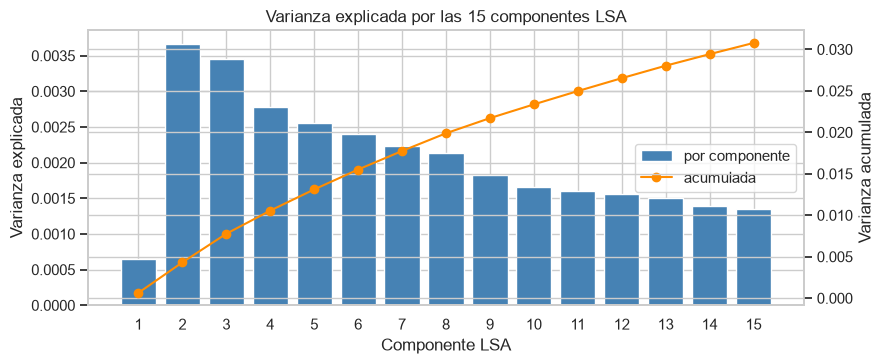

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
componente,1.00000,2.00000,3.00000,4.00000,5.00000,6.00000,7.00000,8.00000,9.00000,10.00000,11.00000,12.00000,13.00000,14.00000,15.00000
varianza_explicada,0.00065,0.00367,0.00345,0.00279,0.00256,0.00240,0.00224,0.00214,0.00182,0.00166,0.00161,0.00156,0.00150,0.00139,0.00135
varianza_acumulada,0.00065,0.00432,0.00777,0.01056,0.01311,0.01551,0.01775,0.01988,0.02171,0.02337,0.02497,0.02653,0.02803,0.02942,0.03077


In [10]:
LSA_N_COMPONENTS = 15
lsa = fit_lsa(X_train_tfidf, n_components=LSA_N_COMPONENTS, random_state=RANDOM_STATE)
ev = explained_variance_table(lsa)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(ev["componente"], ev["varianza_explicada"], color="steelblue", label="por componente")
ax2 = ax.twinx()
ax2.plot(ev["componente"], ev["varianza_acumulada"], "o-", color="darkorange", label="acumulada")
ax.set_xlabel("Componente LSA")
ax.set_ylabel("Varianza explicada")
ax2.set_ylabel("Varianza acumulada")
ax.set_title(f"Varianza explicada por las {LSA_N_COMPONENTS} componentes LSA")
ax.set_xticks(ev["componente"])
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_lsa_varianza.png", dpi=120)
plt.show()
ev.round(5).T

**Interpretación.** Las 15 componentes explican en conjunto ≈ 3 % de la varianza de la matriz
TF-IDF. Este valor es bajo pero **esperable**: la matriz es dispersa, con 26 000 dimensiones y
norma unitaria por fila, de modo que la varianza está repartida en miles de direcciones. En LSA lo
importante no es la varianza sino que las primeras direcciones capturen la estructura semántica
principal, lo que se comprueba a continuación mirando los términos.

In [11]:
top_terms = top_terms_per_component(lsa, feature_names, n_top=12, signed=True)
tabla_topicos = topics_summary(top_terms, n_show=12)
tabla_topicos.to_csv(TAB_DIR / "lsa_topicos_terminos.csv", index=False)
tabla_topicos.style.set_properties(**{"text-align": "left"}).hide(axis="index")

componente,terminos_principales
1,"países, desarrollo, mujeres, políticas, agua, educación, ocde, nivel, embargo, servicios, salud, ingresos"
2,"derechos, derecho, derechos humanos, humanos, internacional, artículo, derecho internacional, energía, agua, ley, justicia, internacionales"
3,"mujeres, agua, género, hombres, energía, educación, laboral, trabajo, pobreza, empleo, ingresos, niños"
4,"estudiantes, educación, escuelas, mujeres, atención, salud, pobreza, aprendizaje, ingresos, energía, escuela, calidad"
5,"mujeres, género, pobreza, salud, atención, hombres, igualdad, ingresos, derecho, igualdad género, derechos humanos, personas"
6,"salud, atención, mujeres, servicios, agua, estudiantes, mental, educación, salud mental, escuelas, género, atención primaria"
7,"agua, energía, aguas, salud, atención, energética, subterráneas, renovables, residuales, aguas residuales, aguas subterráneas, gestión"
8,"energía, climático, cambio climático, pobreza, cambio, desarrollo, agua, países, electricidad, adaptación, renovables, mujeres"
9,"países, pobreza, ocde, climático, ingresos, cambio climático, social, cambio, países ocde, promedio, políticas, mujeres"
10,"pobreza, empleo, género, laboral, energía, trabajadores, trabajo, mercado, mercado laboral, igualdad, sector, igualdad género"


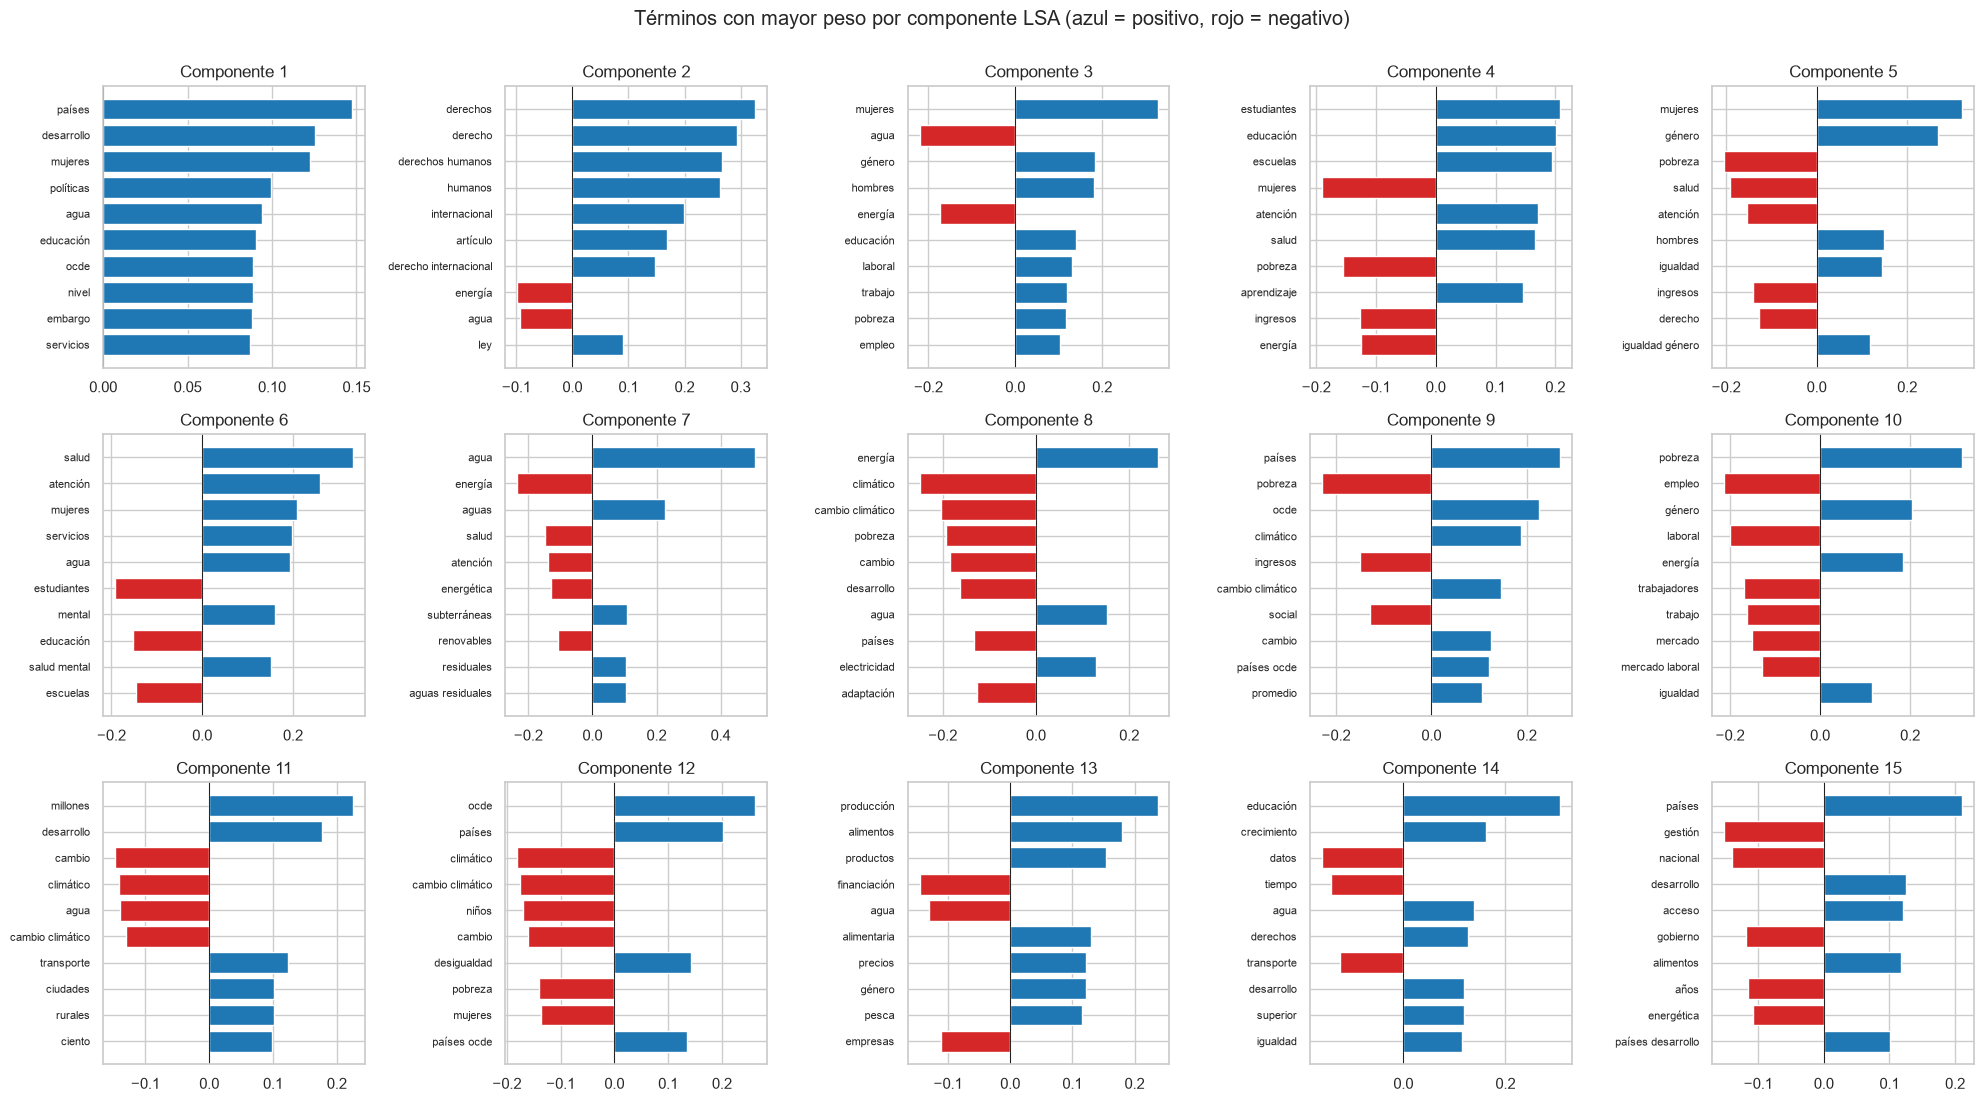

In [12]:
# Visualización: 10 términos con mayor |peso| en cada componente
n_comp = lsa.components_.shape[0]
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for k, ax in zip(range(1, n_comp + 1), axes.ravel()):
    sub = top_terms[(top_terms["componente"] == k) & (top_terms["rank"] <= 10)].iloc[::-1]
    colores = ["#d62728" if p < 0 else "#1f77b4" for p in sub["peso"]]
    ax.barh(sub["termino"], sub["peso"], color=colores)
    ax.set_title(f"Componente {k}")
    ax.tick_params(axis="y", labelsize=8)
    ax.axvline(0, color="black", lw=0.6)
fig.suptitle("Términos con mayor peso por componente LSA (azul = positivo, rojo = negativo)", y=1.0)
plt.tight_layout()
fig.savefig(FIG_DIR / "04_lsa_topicos.png", dpi=110, bbox_inches="tight")
plt.show()

### ¿Los tópicos coinciden con las etiquetas? Contraste cuantitativo

Para no depender solo de la lectura de los términos, se proyectan los documentos de entrenamiento
sobre las componentes y se calcula la **puntuación media de cada componente por ODS real**. Si la
componente *k* tiene media claramente más alta en un ODS, el tópico está capturando esa clase.
(Las etiquetas se usan aquí únicamente para *validar la interpretación*, no para ajustar el LSA,
que sigue siendo no supervisado.)

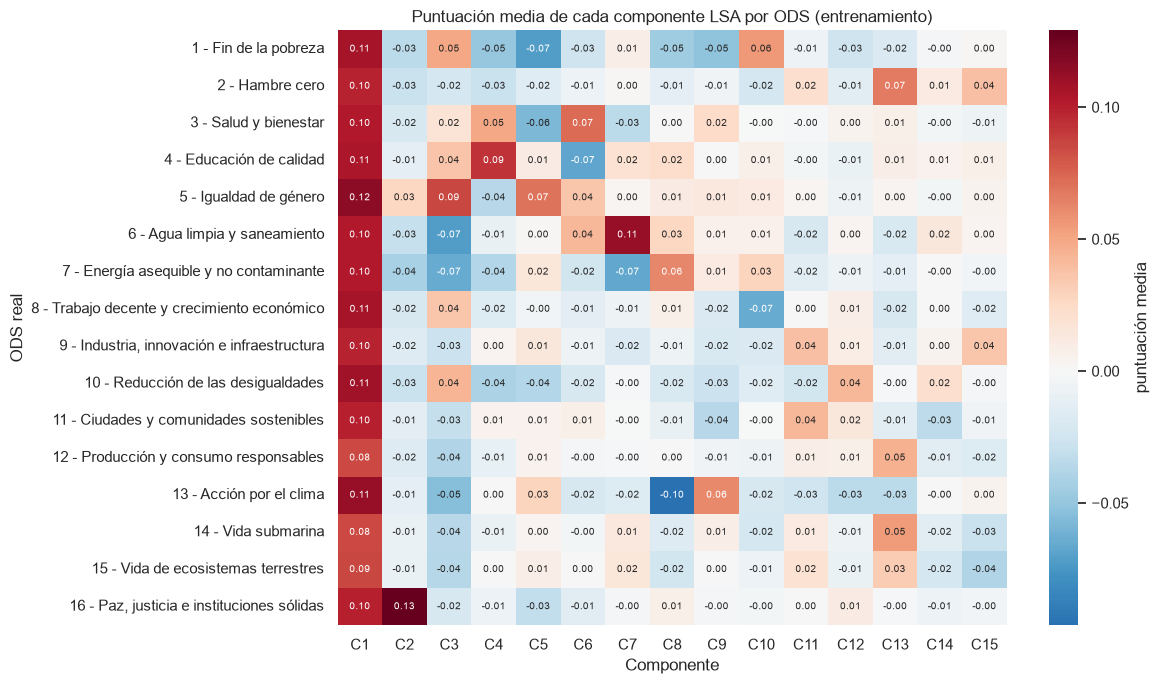

componente,ods_dominantes
C1,5 - Igualdad de género (0.115); 13 - Acción por el clima (0.112); 10 - Reducción de las desigualdades (0.109)
C2,"16 - Paz, justicia e instituciones sólidas (0.129); 5 - Igualdad de género (0.027); 14 - Vida submarina (-0.009)"
C3,5 - Igualdad de género (0.086); 1 - Fin de la pobreza (0.050); 10 - Reducción de las desigualdades (0.044)
C4,4 - Educación de calidad (0.093); 3 - Salud y bienestar (0.049); 11 - Ciudades y comunidades sostenibles (0.006)
C5,5 - Igualdad de género (0.069); 13 - Acción por el clima (0.029); 7 - Energía asequible y no contaminante (0.016)
C6,3 - Salud y bienestar (0.073); 6 - Agua limpia y saneamiento (0.043); 5 - Igualdad de género (0.037)
C7,6 - Agua limpia y saneamiento (0.112); 4 - Educación de calidad (0.020); 15 - Vida de ecosistemas terrestres (0.016)
C8,7 - Energía asequible y no contaminante (0.063); 6 - Agua limpia y saneamiento (0.027); 4 - Educación de calidad (0.024)
C9,13 - Acción por el clima (0.062); 3 - Salud y bienestar (0.024); 5 - Igualdad de género (0.013)
C10,1 - Fin de la pobreza (0.056); 7 - Energía asequible y no contaminante (0.028); 5 - Igualdad de género (0.011)


In [13]:
Z_train = lsa.transform(X_train_tfidf)
scores_ods = component_scores_by_label(Z_train, y_train, ODS_NAMES)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(scores_ods, cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax,
            cbar_kws={"label": "puntuación media"})
ax.set_title("Puntuación media de cada componente LSA por ODS (entrenamiento)")
ax.set_xlabel("Componente")
ax.set_ylabel("ODS real")
plt.tight_layout()
fig.savefig(FIG_DIR / "05_lsa_componentes_por_ods.png", dpi=120)
plt.show()

dominantes = dominant_ods_per_component(scores_ods, n=3)
dominantes.to_csv(TAB_DIR / "lsa_ods_dominantes.csv", index=False)
dominantes.style.hide(axis="index")

### Interpretación cualitativa de los tópicos frente a los ODS

Con las dos fuentes de evidencia (términos con mayor peso y ODS con mayor puntuación media) se
interpretan las componentes. Como en LSA una componente puede tener **dos polos** (términos con
peso positivo y negativo), se indica cuál polo se lee.

| Comp. | Términos con mayor peso | Lectura del tópico | ODS relacionado(s) | Evidencia cuantitativa |
|---|---|---|---|---|
| **C1** | países, desarrollo, mujeres, políticas, agua, educación, ocde | Eje "genérico" de desarrollo y políticas públicas: es la dirección media del corpus, típica de la primera componente de LSA. | Transversal (ODS 5, 13, 10 con medias casi iguales) | No discrimina: medias ≈ 0.11 en muchos ODS. |
| **C2** | derechos, derecho, derechos humanos, internacional, artículo, ley, justicia | Marco jurídico, derecho internacional y derechos humanos. | **ODS 16** Paz, justicia e instituciones sólidas | Media 0.129 en ODS 16 vs. ≤ 0.03 en el resto: la asociación más nítida de todas. |
| **C3** | *(+)* mujeres, género, hombres, laboral, trabajo, empleo, ingresos · *(−)* agua, energía, gestión, cambio climático | Contraste "dimensión social/laboral" vs. "recursos naturales y clima". | *(+)* ODS 5, 1, 10 · *(−)* ODS 6, 7, 13 | Positiva en ODS 5 (0.086) y negativa en los ODS ambientales. |
| **C4** | estudiantes, educación, escuelas, aprendizaje, escuela, docentes, primaria | Sistema educativo: alumnos, escuelas, docentes. | **ODS 4** Educación de calidad | Media 0.093 en ODS 4; siguiente ODS 3 con 0.049. |
| **C5** | mujeres, género, hombres, igualdad, igualdad género, participación | Igualdad de género y participación de las mujeres. | **ODS 5** Igualdad de género | Media 0.069 en ODS 5; ≤ 0.03 en los demás. |
| **C6** | salud, atención, servicios, mental, salud mental, atención primaria, pacientes · *(−)* estudiantes, escuelas | Servicios de salud y atención primaria (en oposición a educación). | **ODS 3** Salud y bienestar | Media 0.073 en ODS 3. |
| **C7** | agua, aguas subterráneas, aguas residuales, hídricos, agua potable · *(−)* energía, renovables | Gestión del recurso hídrico y saneamiento (en oposición a energía). | **ODS 6** Agua limpia y saneamiento | Media 0.112 en ODS 6, la segunda asociación más fuerte. |
| **C8** | energía, electricidad, renovables, energías renovables, energética · *(−)* cambio climático, adaptación, financiación | Acceso a energía y renovables, separado del discurso de adaptación climática. | **ODS 7** Energía asequible y no contaminante (polo −: ODS 13) | Media 0.063 en ODS 7. |
| **C9** | países ocde, cambio climático, promedio · *(−)* pobreza, ingresos, hogares, pobres | Estadística comparada OCDE sobre clima vs. pobreza de hogares. | *(+)* **ODS 13** Acción por el clima · *(−)* ODS 1 | Media 0.062 en ODS 13. |
| **C10** | *(−)* empleo, laboral, trabajadores, mercado laboral, sector · *(+)* pobreza, igualdad género, infantil | Mercado laboral y trabajadores (polo negativo) frente a pobreza infantil/género. | *(−)* **ODS 8** Trabajo decente · *(+)* ODS 1 | Media 0.056 en ODS 1 (polo +). |
| **C11** | millones, transporte, ciudades, rurales, zonas, público, gobierno | Infraestructura urbana, transporte, zonas rurales/urbanas. | **ODS 11** Ciudades sostenibles / ODS 9 Infraestructura | Medias 0.042 (ODS 11) y 0.039 (ODS 9). |
| **C13** | producción, alimentos, alimentaria, precios, pesca, seguridad alimentaria | Sistemas alimentarios, producción y pesca. | **ODS 2** Hambre cero, con ODS 14 Vida submarina y ODS 12 Producción responsable | Medias 0.067 / 0.054 / 0.046. |

**Conclusiones del LSA.**

- Al menos **ocho componentes** (C2, C4, C5, C6, C7, C8, C9, C13) se corresponden de forma clara y
  verificable con un ODS concreto; otras (C3, C10, C11) capturan *contrastes* entre familias de ODS
  (social vs. ambiental, laboral vs. pobreza, urbano vs. clima).
- Los tópicos **no son uno a uno con los ODS**, ni tiene por qué serlo: LSA es no supervisado y
  ordena direcciones por varianza, no por etiqueta. ODS con vocabulario compartido (1 Pobreza /
  10 Desigualdades; 9 Infraestructura / 11 Ciudades; 12 Consumo / 14 Vida submarina / 15 Ecosistemas)
  aparecen mezclados en las mismas componentes, lo que anticipa cuáles serán las confusiones del
  clasificador.
- La primera componente es un eje genérico sin valor discriminante, comportamiento habitual en LSA
  sobre TF-IDF.
- Con 15 dimensiones se captura la estructura temática gruesa, pero es evidente que **15 no basta
  para separar 16 clases** con buena precisión: por eso, para clasificar, se buscará un número de
  componentes mayor (sección 9).

## 8. Pipeline de clasificación (Actividad 3)

### Arquitectura

```
texto crudo -> TfidfVectorizer(preprocessor=clean_text, stopwords, 1-2 gramas, TF-IDF)
            -> TruncatedSVD(n_components=k)      <- reducción de dimensionalidad (LSA)
            -> Normalizer(L2)                    <- paso clásico de LSA
            -> clasificador lineal (class_weight="balanced")
```

Todo va dentro de un único `Pipeline` de scikit-learn. Esto garantiza que **en cada fold de la
validación cruzada el vocabulario, el IDF y el SVD se ajusten solo con el fold de entrenamiento**,
y que el objeto que se serializa para la app sea idéntico al que se evaluó.

### Justificación de la reducción de dimensionalidad

Se reutiliza la misma técnica de la Actividad 2 (`TruncatedSVD` / LSA), como permite el enunciado,
porque:

- Trabaja directamente sobre la matriz dispersa TF-IDF (no hay que densificar 26 000 columnas).
- Proyecta los documentos a un espacio **denso y semántico**: dos textos que usan sinónimos o
  vocabulario relacionado ("escuela"/"docentes"/"alumnos") quedan cerca aunque no compartan
  términos exactos, lo que ayuda a generalizar.
- Reduce el ruido de términos raros y acelera el clasificador.

Ahora bien, **el número de componentes útil para clasificar no es el mismo que para interpretar
tópicos**: con 15 componentes se obtienen ejes legibles, pero se pierde demasiada información para
separar 16 clases. Por ello el número de componentes es un **hiperparámetro** que se busca en
{100, 200, 300} en la sección 9. Para poner esas cifras en contexto se calculan dos referencias:
el pipeline con las 15 componentes del LSA interpretativo y un pipeline **sin** reducción.

El `Normalizer` L2 tras el SVD hace que cada documento tenga norma 1 en el espacio latente, de modo
que el clasificador lineal compara documentos por similitud coseno (la medida natural en LSA) y no
se ve afectado por la distinta escala de las componentes.

### Justificación del algoritmo de clasificación

Se comparan dos clasificadores **lineales**:

| Candidato | Por qué es adecuado | Hiperparámetro |
|---|---|---|
| `LogisticRegression` (multinomial) | Produce probabilidades calibradas por clase, útil para mostrar "top-3" al usuario; regularización L2 controla el sobreajuste; entrena rápido. | `C` (inverso de la regularización) |
| `LinearSVC` | Máximo margen; históricamente el clasificador de referencia para texto con TF-IDF/LSA; muy eficiente con miles de rasgos; robusto a rasgos correlacionados. | `C` |

Razones para restringirse a modelos lineales: (i) en espacios de texto de alta dimensión las clases
suelen ser (casi) linealmente separables y los modelos no lineales (árboles, boosting, kernels RBF)
rara vez mejoran y cuestan órdenes de magnitud más; (ii) sus coeficientes son interpretables;
(iii) con ~7 700 documentos el riesgo de sobreajuste se controla bien con la regularización `C`.
No se consideran redes neuronales/transformers porque el enunciado pide una solución basada en
BOW + TF-IDF + reducción de dimensionalidad.

Ambos usan `class_weight="balanced"` (peso inverso a la frecuencia de la clase) para que las clases
pequeñas (ODS 12, 15, 9) no queden relegadas.

### Justificación de las métricas

- **F1 macro** (métrica de selección): media del F1 de las 16 clases con igual peso. Es la
  adecuada porque las clases están desbalanceadas y, desde el punto de vista del usuario (UNFPA),
  clasificar bien un texto de ODS 12 importa tanto como uno de ODS 16.
- **Accuracy**: intuitiva pero dominada por las clases grandes; se reporta como complemento.
- **Precision y recall macro**: descomponen el F1 y muestran si el modelo tiende a sobre- o
  sub-predecir clases.
- **F1 ponderado**: F1 por clase ponderado por soporte; refleja el rendimiento "promedio por texto".
- **Reporte por clase y matriz de confusión**: identifican qué ODS se confunden entre sí.

In [14]:
def build_classification_pipeline(classifier=None, n_components=200, random_state=RANDOM_STATE):
    '''Pipeline completo: limpieza + TF-IDF -> TruncatedSVD -> Normalizer(L2) -> clasificador.'''
    if classifier is None:
        classifier = LogisticRegression(max_iter=3000, class_weight="balanced", C=10.0, random_state=random_state)
    return Pipeline(
        steps=[
            ("tfidf", build_tfidf_vectorizer()),
            ("svd", TruncatedSVD(n_components=n_components, algorithm="randomized", n_iter=7, random_state=random_state)),
            ("norm", Normalizer(copy=False)),
            ("clf", classifier),
        ]
    )


def candidate_search_spaces(random_state=RANDOM_STATE):
    '''Rejillas de búsqueda para los dos clasificadores lineales candidatos.'''
    return {
        "LogisticRegression": {
            "estimator": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=random_state),
            "param_grid": {"svd__n_components": [100, 200, 300], "clf__C": [1.0, 10.0, 30.0]},
        },
        "LinearSVC": {
            "estimator": LinearSVC(class_weight="balanced", random_state=random_state),
            "param_grid": {"svd__n_components": [100, 200, 300], "clf__C": [0.3, 1.0, 3.0]},
        },
    }


def run_grid_search(pipeline, param_grid, X, y, cv_splits=5, scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=-1):
    '''GridSearchCV con validación cruzada estratificada; todo el pipeline (TF-IDF y SVD incluidos)
    se reajusta dentro de cada fold, sin fuga de información.'''
    cv_ = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
        refit=scoring,
        cv=cv_,
        n_jobs=n_jobs,
        verbose=0,
        return_train_score=False,
    )
    search.fit(X, y)
    return search


def cv_results_table(search, model_name=None):
    '''Tabla legible con los resultados de la búsqueda, ordenada por F1 macro.'''
    res = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in res.columns if c.startswith("param_")]
    out = res[param_cols + ["mean_test_f1_macro", "std_test_f1_macro", "mean_test_accuracy", "mean_fit_time"]].copy()
    out.columns = [c.replace("param_", "") for c in param_cols] + ["f1_macro_cv", "f1_macro_std", "accuracy_cv", "fit_time_s"]
    if model_name:
        out.insert(0, "modelo", model_name)
    return out.sort_values("f1_macro_cv", ascending=False).reset_index(drop=True)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Referencia A: mismo pipeline con las 15 componentes del LSA interpretativo
pipe_lsa15 = build_classification_pipeline(n_components=LSA_N_COMPONENTS, random_state=RANDOM_STATE)
t0 = time.time()
f1_lsa15 = cross_val_score(pipe_lsa15, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"Referencia A · TF-IDF -> SVD(15) -> LogReg : F1 macro CV = {f1_lsa15.mean():.4f} ± {f1_lsa15.std():.4f}  ({time.time()-t0:.0f} s)")

# Referencia B: sin reducción de dimensionalidad (cota superior de lo que aporta el vocabulario completo)
pipe_sin_svd = Pipeline([
    ("tfidf", build_tfidf_vectorizer()),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", C=10.0, random_state=RANDOM_STATE)),
])
t0 = time.time()
f1_sin_svd = cross_val_score(pipe_sin_svd, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"Referencia B · TF-IDF -> LogReg (sin SVD)  : F1 macro CV = {f1_sin_svd.mean():.4f} ± {f1_sin_svd.std():.4f}  ({time.time()-t0:.0f} s)")

pipe_base = build_classification_pipeline(random_state=RANDOM_STATE)
pipe_base

Referencia A · TF-IDF -> SVD(15) -> LogReg : F1 macro CV = 0.7150 ± 0.0084  (9 s)


Referencia B · TF-IDF -> LogReg (sin SVD)  : F1 macro CV = 0.8697 ± 0.0073  (18 s)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function cle...00265594B9170>
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['a', 'además', ...]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.","'(?u)\\b[a-záéíóúüñ]{3,}\\b'"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If

**Interpretación de las referencias.** Con solo 15 componentes el F1 macro cae a ≈ 0.71: esas
direcciones capturan los grandes temas pero no la granularidad necesaria para 16 clases. Sin
reducción alguna se alcanza ≈ 0.87, que actúa como cota de referencia. El objetivo del grid search es
encontrar cuántas componentes hacen falta para acercarse a esa cota manteniendo una representación
compacta (cientos de dimensiones densas en lugar de 26 000 dispersas).

## 9. Búsqueda de hiperparámetros y validación cruzada

Se usa `GridSearchCV` con `StratifiedKFold(5, shuffle=True, random_state=42)` sobre **el conjunto
de entrenamiento únicamente**, optimizando F1 macro (`refit="f1_macro"`) y registrando también la
accuracy. La estratificación asegura que cada fold conserve las proporciones de las 16 clases.

Rejilla (función `candidate_search_spaces` de la sección 8):

| Modelo | `svd__n_components` | `clf__C` | Ajustes (5 folds) |
|---|---|---|---|
| LogisticRegression | 100, 200, 300 | 1, 10, 30 | 45 |
| LinearSVC | 100, 200, 300 | 0.3, 1, 3 | 45 |

`C` se explora en escala logarítmica (es lo habitual para regularización) alrededor de los valores
por defecto de cada algoritmo. El número de componentes se explora en un rango amplio porque la
sección 8 mostró que 15 es insuficiente. En cada ajuste se recalculan TF-IDF y SVD sobre el fold de
entrenamiento, así que la búsqueda es costosa (≈ 10-15 min) pero libre de fugas.

In [15]:
resultados = {}
tablas = []
for nombre, spec in candidate_search_spaces(random_state=RANDOM_STATE).items():
    t0 = time.time()
    pipe = build_classification_pipeline(classifier=spec["estimator"], random_state=RANDOM_STATE)
    search = run_grid_search(pipe, spec["param_grid"], X_train, y_train, cv_splits=5, random_state=RANDOM_STATE, n_jobs=6)
    resultados[nombre] = search
    tablas.append(cv_results_table(search, nombre))
    print(f"{nombre:20s} mejor F1 macro CV = {search.best_score_:.4f}  params = {search.best_params_}  ({time.time()-t0:.0f} s)")

tabla_cv = pd.concat(tablas, ignore_index=True).sort_values("f1_macro_cv", ascending=False).reset_index(drop=True)
tabla_cv.to_csv(TAB_DIR / "grid_search_resultados.csv", index=False)
tabla_cv.round(4)

LogisticRegression   mejor F1 macro CV = 0.8437  params = {'clf__C': 1.0, 'svd__n_components': 300}  (207 s)


LinearSVC            mejor F1 macro CV = 0.8487  params = {'clf__C': 0.3, 'svd__n_components': 300}  (256 s)


,modelo,clf__C,svd__n_components,f1_macro_cv,f1_macro_std,accuracy_cv,fit_time_s
0,LinearSVC,0.3,300,0.8487,0.0056,0.8742,36.5041
1,LogisticRegression,1.0,300,0.8437,0.0044,0.8681,28.0351
2,LinearSVC,0.3,200,0.8428,0.0042,0.8690,31.4207
3,LinearSVC,1.0,300,0.8414,0.0059,0.8678,42.8346
4,LogisticRegression,1.0,200,0.8401,0.0046,0.8657,22.1219
5,LinearSVC,1.0,200,0.8376,0.0051,0.8654,30.3849
6,LogisticRegression,10.0,300,0.8367,0.0067,0.8630,34.4602
7,LogisticRegression,10.0,200,0.8346,0.0077,0.8608,23.5055
8,LinearSVC,0.3,100,0.8344,0.0071,0.8630,20.9754
9,LinearSVC,3.0,200,0.8336,0.0068,0.8624,30.2468


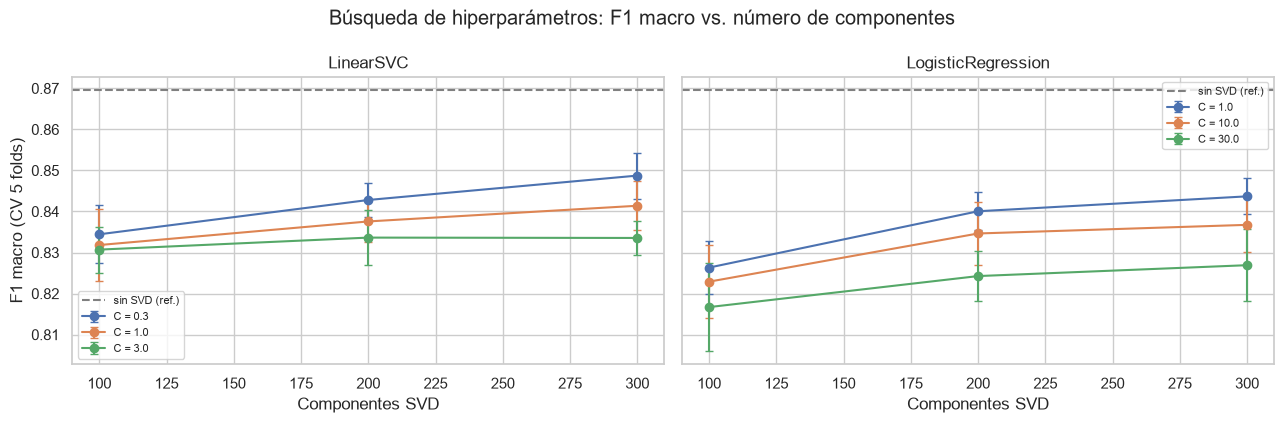

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
for ax, (nombre, sub) in zip(axes, tabla_cv.groupby("modelo")):
    for c, g in sub.groupby("clf__C"):
        g = g.sort_values("svd__n_components")
        ax.errorbar(g["svd__n_components"], g["f1_macro_cv"], yerr=g["f1_macro_std"], marker="o", capsize=3, label=f"C = {c}")
    ax.axhline(f1_sin_svd.mean(), ls="--", c="gray", label="sin SVD (ref.)")
    ax.set_title(nombre)
    ax.set_xlabel("Componentes SVD")
    ax.legend(fontsize=8)
axes[0].set_ylabel("F1 macro (CV 5 folds)")
fig.suptitle("Búsqueda de hiperparámetros: F1 macro vs. número de componentes")
plt.tight_layout()
fig.savefig(FIG_DIR / "06_grid_search.png", dpi=120)
plt.show()

In [17]:
mejor_nombre = max(resultados, key=lambda k: resultados[k].best_score_)
mejor_search = resultados[mejor_nombre]
best_pipeline = mejor_search.best_estimator_

print("Modelo seleccionado :", mejor_nombre)
print("Hiperparámetros     :", mejor_search.best_params_)
print(f"F1 macro CV         : {mejor_search.best_score_:.4f}")
idx = mejor_search.best_index_
print(f"Accuracy CV         : {mejor_search.cv_results_['mean_test_accuracy'][idx]:.4f}")
print("\nComparativa (F1 macro CV):")
print(f"  SVD 15 comp. (LSA interpretativo) : {f1_lsa15.mean():.4f}")
print(f"  {mejor_nombre} + SVD {mejor_search.best_params_['svd__n_components']} comp. : {mejor_search.best_score_:.4f}")
print(f"  Sin reducción de dimensionalidad  : {f1_sin_svd.mean():.4f}")

Modelo seleccionado : LinearSVC
Hiperparámetros     : {'clf__C': 0.3, 'svd__n_components': 300}
F1 macro CV         : 0.8487
Accuracy CV         : 0.8742

Comparativa (F1 macro CV):
  SVD 15 comp. (LSA interpretativo) : 0.7150
  LinearSVC + SVD 300 comp. : 0.8487
  Sin reducción de dimensionalidad  : 0.8697


**Interpretación de la búsqueda.**

- **Más componentes -> mejor F1**, de forma monótona en ambos algoritmos: 100 -> 200 -> 300 aporta
  aproximadamente +0.8 y +0.6 puntos de F1 macro. La curva se va aplanando y con 300 componentes se
  queda a ~2 puntos de la referencia sin reducción (0.870), lo que indica que **300 dimensiones
  densas retienen casi toda la información discriminante de 26 000 dimensiones dispersas**
  (reducción de ~99 %).
- **La regularización importa**: en ambos modelos gana el `C` más pequeño explorado (mayor
  regularización). Con `C` grande el modelo sobreajusta las componentes ruidosas y el F1 cae hasta
  3 puntos.
- **`LinearSVC` (C = 0.3, 300 comp.) es el mejor**, con F1 macro CV ≈ 0.849 ± 0.006 frente a
  0.844 ± 0.004 de la regresión logística. La diferencia es pequeña (dentro de una desviación
  estándar) pero consistente en todas las configuraciones, y `LinearSVC` entrena el doble de
  rápido. Se selecciona `LinearSVC`.
- Como contrapartida, `LinearSVC` no produce probabilidades; para la evidencia de la sección 11 y
  la app se usa el **margen de decisión** (`decision_function`) para ordenar los ODS candidatos,
  aclarando que es un ranking y no una probabilidad.
- La desviación estándar entre folds (≈ 0.005) es baja: la estimación es estable y la elección no
  depende del azar del split.

`GridSearchCV` con `refit=True` reentrena el mejor pipeline con **todo** el conjunto de
entrenamiento; ese es el modelo que se evalúa en test y se serializa.

## 10. Evaluación final sobre test (Actividad 4)

Esta es la **única** vez que se usa `X_test`/`y_test`: 1 932 textos que el modelo nunca ha visto,
ni directamente ni a través de la selección de hiperparámetros. Las métricas que siguen son, por
tanto, una estimación honesta del desempeño en producción sobre textos de la misma distribución.

In [18]:
def compute_metrics(y_true, y_pred):
    '''Métricas globales en una tabla de una fila.'''
    return pd.DataFrame(
        {
            "accuracy": [accuracy_score(y_true, y_pred)],
            "precision_macro": [precision_score(y_true, y_pred, average="macro", zero_division=0)],
            "recall_macro": [recall_score(y_true, y_pred, average="macro", zero_division=0)],
            "f1_macro": [f1_score(y_true, y_pred, average="macro", zero_division=0)],
            "f1_weighted": [f1_score(y_true, y_pred, average="weighted", zero_division=0)],
        }
    )


def per_class_report(y_true, y_pred):
    '''classification_report como DataFrame con el nombre de cada ODS.'''
    rep_ = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    rows = [{"ODS": int(k), "nombre": ODS_NAMES.get(int(k), ""), **v} for k, v in rep_.items() if k.isdigit()]
    out = pd.DataFrame(rows).sort_values("ODS").reset_index(drop=True)
    out["support"] = out["support"].astype(int)
    return out


def plot_confusion_matrix(y_true, y_pred, labels=None, normalize=True, ax=None, title=None):
    '''Matriz de confusión (normalizada por fila = recall por clase).'''
    labels = list(labels) if labels is not None else sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true" if normalize else None)
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", xticklabels=labels, yticklabels=labels,
        cbar_kws={"label": "proporción de la fila" if normalize else "conteo"}, ax=ax, annot_kws={"size": 7},
    )
    ax.set_xlabel("ODS predicho")
    ax.set_ylabel("ODS real")
    ax.set_title(title or ("Matriz de confusión (normalizada por clase real)" if normalize else "Matriz de confusión"))
    return ax


def most_confused_pairs(y_true, y_pred, n=8):
    '''Pares (real, predicho) con más errores.'''
    df_ = pd.DataFrame({"real": np.asarray(y_true), "predicho": np.asarray(y_pred)})
    err = df_[df_["real"] != df_["predicho"]].value_counts().reset_index(name="errores").head(n)
    err["real"] = err["real"].map(lambda k: f"{k} - {ODS_NAMES[k]}")
    err["predicho"] = err["predicho"].map(lambda k: f"{k} - {ODS_NAMES[k]}")
    return err


t0 = time.time()
y_pred = best_pipeline.predict(X_test)
print(f"Predicción de {len(X_test)} textos en {time.time()-t0:.2f} s")

metricas_test = compute_metrics(y_test, y_pred)
metricas_test.insert(0, "modelo", f"{mejor_nombre} + SVD({mejor_search.best_params_['svd__n_components']})")
metricas_test.to_csv(TAB_DIR / "metricas_test.csv", index=False)
metricas_test.round(4)

Predicción de 1932 textos en 0.41 s


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,LinearSVC + SVD(300),0.8846,0.8533,0.8552,0.8538,0.8846


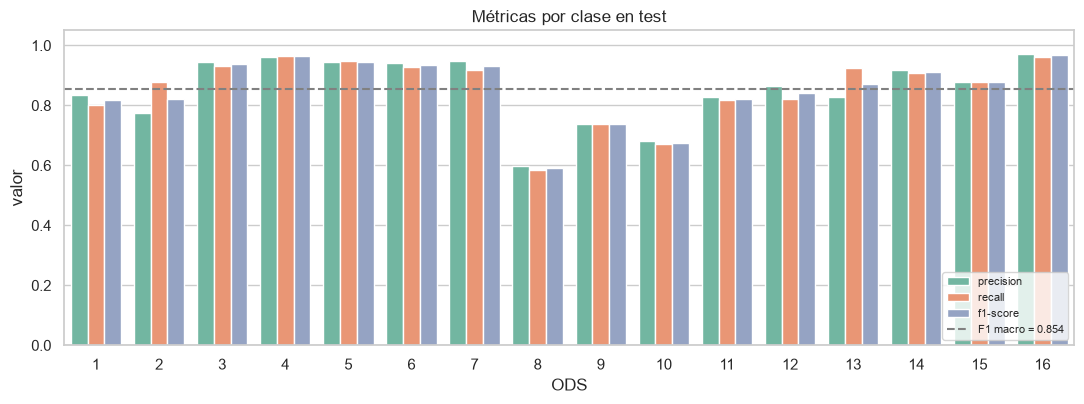

,ODS,nombre,precision,recall,f1-score,support
0,1,Fin de la pobreza,0.835,0.802,0.818,101
1,2,Hambre cero,0.774,0.878,0.823,74
2,3,Salud y bienestar,0.944,0.933,0.938,179
3,4,Educación de calidad,0.961,0.966,0.964,205
4,5,Igualdad de género,0.944,0.949,0.946,214
5,6,Agua limpia y saneamiento,0.942,0.928,0.935,139
6,7,Energía asequible y no contaminante,0.948,0.918,0.932,158
7,8,Trabajo decente y crecimiento económico,0.598,0.584,0.591,89
8,9,"Industria, innovación e infraestructura",0.739,0.739,0.739,69
9,10,Reducción de las desigualdades,0.681,0.671,0.676,70


In [19]:
reporte = per_class_report(y_test, y_pred)
reporte.to_csv(TAB_DIR / "reporte_por_clase_test.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 4.2))
rep_long = reporte.melt(id_vars=["ODS"], value_vars=["precision", "recall", "f1-score"], var_name="métrica", value_name="valor")
sns.barplot(data=rep_long, x="ODS", y="valor", hue="métrica", ax=ax, palette="Set2")
ax.axhline(metricas_test["f1_macro"].iloc[0], ls="--", c="gray", label=f"F1 macro = {metricas_test['f1_macro'].iloc[0]:.3f}")
ax.set_ylim(0, 1.05)
ax.set_title("Métricas por clase en test")
ax.set_ylabel("valor")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / "07_metricas_por_clase.png", dpi=120)
plt.show()
reporte.round(3)

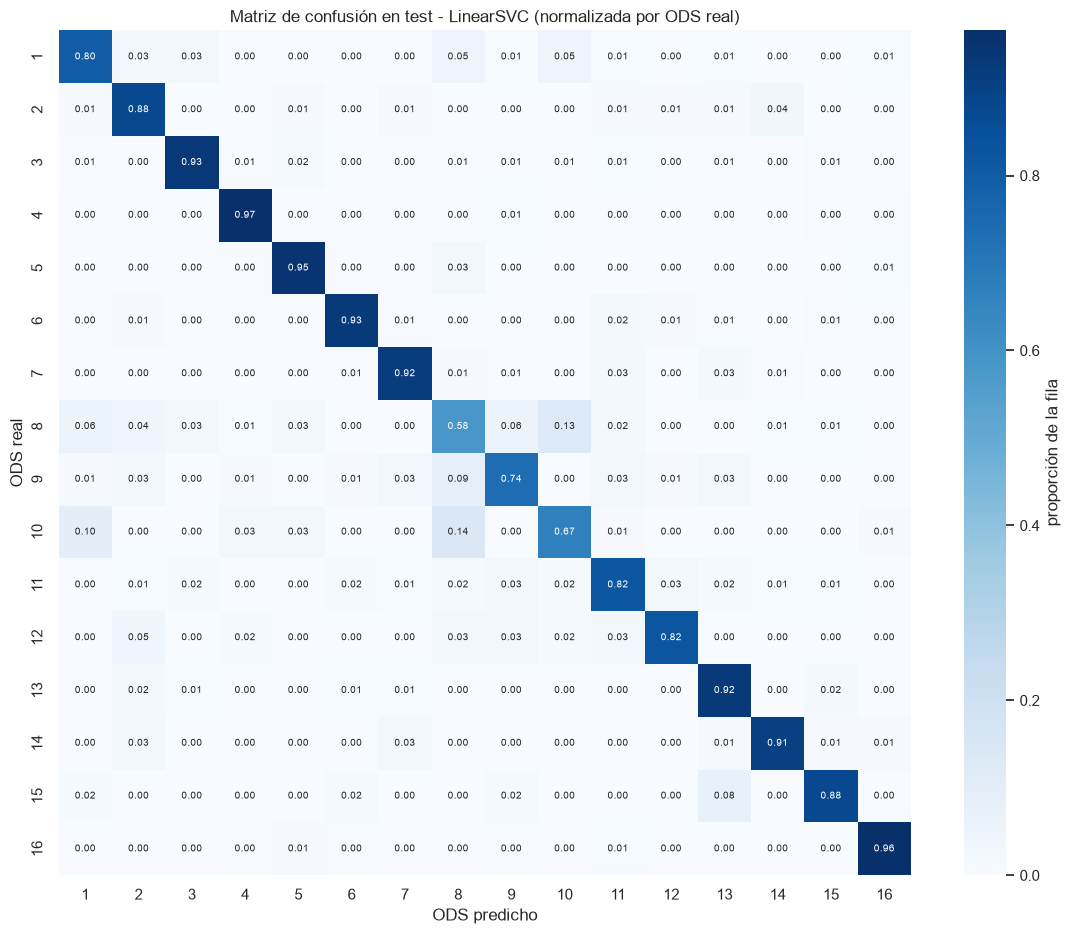

Pares (real -> predicho) con más errores:


,real,predicho,errores
0,8 - Trabajo decente y crecimiento económico,10 - Reducción de las desigualdades,12
1,10 - Reducción de las desigualdades,8 - Trabajo decente y crecimiento económico,10
2,10 - Reducción de las desigualdades,1 - Fin de la pobreza,7
3,5 - Igualdad de género,8 - Trabajo decente y crecimiento económico,6
4,"9 - Industria, innovación e infraestructura",8 - Trabajo decente y crecimiento económico,6
5,15 - Vida de ecosistemas terrestres,13 - Acción por el clima,5
6,8 - Trabajo decente y crecimiento económico,1 - Fin de la pobreza,5
7,8 - Trabajo decente y crecimiento económico,"9 - Industria, innovación e infraestructura",5
8,1 - Fin de la pobreza,10 - Reducción de las desigualdades,5
9,1 - Fin de la pobreza,8 - Trabajo decente y crecimiento económico,5


In [20]:
clases = sorted(y.unique())
fig, ax = plt.subplots(figsize=(11.5, 9.5))
plot_confusion_matrix(y_test, y_pred, labels=clases, normalize=True, ax=ax,
                      title=f"Matriz de confusión en test - {mejor_nombre} (normalizada por ODS real)")
plt.tight_layout()
fig.savefig(FIG_DIR / "08_matriz_confusion.png", dpi=120)
plt.show()

print("Pares (real -> predicho) con más errores:")
most_confused_pairs(y_test, y_pred, n=10)

**Interpretación de la evaluación en test.**

- **F1 macro = 0.854 y accuracy = 0.885 en test**, frente a 0.849 / 0.874 en validación cruzada:
  las métricas en test son incluso ligeramente superiores a la estimación por CV, así que no hay
  sobreajuste al procedimiento de selección y la estimación por CV era fiable.
- **Precision macro ≈ recall macro**: el modelo no está sesgado a sobre-predecir clases grandes,
  efecto directo de `class_weight="balanced"`. El F1 ponderado es algo mayor que el macro porque
  las clases grandes (4, 5, 16) están entre las mejor clasificadas.
- **Clases con mejor desempeño** (F1 > 0.9): ODS 16 *Justicia* (0.967), ODS 4 *Educación*
  (0.964), ODS 5 *Género* (0.946), ODS 3 *Salud* (0.938), ODS 6 *Agua* (0.935), ODS 7 *Energía*
  (0.932) y ODS 14 *Vida submarina* (0.913) - justo las que tenían una componente LSA nítida en la
  sección 7: vocabulario propio y poco compartido.
- **Clases más difíciles** (F1 < 0.75): ODS 8 *Trabajo decente* (0.591), ODS 10 *Desigualdades*
  (0.676) y ODS 9 *Infraestructura* (0.739). Las tres tienen **vocabulario fuertemente compartido**
  con otros ODS (empleo/ingresos/crecimiento aparecen en 1, 8, 9 y 10) y soporte medio-bajo
  (343-446 textos).
- La matriz de confusión y la tabla de pares muestran que los errores no son aleatorios sino
  **semánticamente coherentes**: el bloque **8 Trabajo <-> 10 Desigualdades <-> 1 Pobreza** concentra
  los mayores errores (12 + 10 + 7 + 5 + 5 + 5 textos), seguido de 9 Infraestructura -> 8 Trabajo,
  15 Ecosistemas -> 13 Clima y 5 Género -> 8 Trabajo. Son exactamente las familias de ODS que el LSA
  agrupaba en una misma componente o en polos de un mismo contraste (sección 7). Muchos de esos
  textos serían ambiguos incluso para un anotador humano (un texto sobre empleo de personas pobres
  puede etiquetarse como ODS 1 u ODS 8).
- **Efecto del desbalance**: es menor de lo esperado gracias a `class_weight="balanced"`: la
  clase más pequeña, ODS 12 (62 textos de test), obtiene F1 = 0.84, y ODS 15 y 9 (66-69 textos)
  0.88 y 0.74; mientras que ODS 8, con casi el doble de soporte, es la peor. La causa dominante de
  error es la **superposición temática**, no el tamaño de la clase.

## 11. Evidencia de clasificación en textos no vistos

Se muestran predicciones individuales sobre textos del **conjunto de test** (nunca usados para
entrenar ni para elegir hiperparámetros): primero una muestra aleatoria (semilla fija) y después
algunos errores informativos. Para cada texto se listan los tres ODS con mayor margen de decisión,
que permiten ver si la clase correcta era la segunda opción del modelo.

In [21]:
def sample_predictions_table(texts, y_true, y_pred, indices, scores=None, classes=None, max_chars=220, score_label="top3_puntuaciones"):
    '''Tabla de evidencia con fragmento, ODS real, ODS predicho, acierto y top-3 por puntuación.'''
    texts = pd.Series(texts).reset_index(drop=True)
    y_true = pd.Series(np.asarray(y_true)).reset_index(drop=True)
    y_pred = pd.Series(np.asarray(y_pred)).reset_index(drop=True)
    rows = []
    for i in indices:
        t = texts.iloc[i]
        row = {
            "idx_test": int(i),
            "fragmento": t[:max_chars] + ("…" if len(t) > max_chars else ""),
            "ODS_real": f"{y_true.iloc[i]} - {ODS_NAMES[int(y_true.iloc[i])]}",
            "ODS_predicho": f"{y_pred.iloc[i]} - {ODS_NAMES[int(y_pred.iloc[i])]}",
            "acierto": "✔" if y_true.iloc[i] == y_pred.iloc[i] else "✘",
        }
        if scores is not None and classes is not None:
            p = scores[i]
            order = np.argsort(p)[::-1][:3]
            row[score_label] = "; ".join(f"ODS {classes[j]}: {p[j]:.2f}" for j in order)
        rows.append(row)
    return pd.DataFrame(rows)


X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)
margenes = best_pipeline.decision_function(X_test)
clases_modelo = best_pipeline.named_steps["clf"].classes_

rng = np.random.default_rng(RANDOM_STATE)
idx_muestra = sorted(rng.choice(len(X_test_r), size=8, replace=False))
evidencia = sample_predictions_table(X_test_r, y_test_r, y_pred, idx_muestra, scores=margenes, classes=clases_modelo,
                                     score_label="top3_margen_decision", max_chars=260)
evidencia.to_csv(TAB_DIR / "evidencia_predicciones_test.csv", index=False)
print(f"Aciertos en la muestra: {(evidencia['acierto'] == '✔').sum()} de {len(evidencia)}")
evidencia.style.set_properties(subset=["fragmento"], **{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index")

Aciertos en la muestra: 8 de 8


idx_test,fragmento,ODS_real,ODS_predicho,acierto,top3_margen_decision
165,"Los bosques mongoles albergan 140 especies de árboles y arbustos, las principales especies formadoras de bosques son el alerce (Larix sibirica), la especie arbórea dominante en Mongolia, el pino (Pinus silvestris), el cedro, la picea, el abeto, el abedul, el á…",15 - Vida de ecosistemas terrestres,15 - Vida de ecosistemas terrestres,✔,ODS 15: 1.88; ODS 14: 0.08; ODS 4: -1.25
171,"En total, en 2016, se notificaron 30 273 casos de sarampión en los 21 aimags. A nivel mundial, el sarampión sigue siendo una de las principales causas de muerte en niños menores de 5 años, a pesar de la disponibilidad de una vacuna segura y eficaz que previene…",3 - Salud y bienestar,3 - Salud y bienestar,✔,ODS 3: -0.08; ODS 2: -0.23; ODS 11: -0.75
835,"Cuando la discusión sobre la expansión global del poder judicial se encuentra con la jurisprudencia del Tribunal de Justicia de las Comunidades Europeas, se toma como ejemplo para mostrar cómo el viento del common law del Tribunal Supremo de los Estados Unidos…","16 - Paz, justicia e instituciones sólidas","16 - Paz, justicia e instituciones sólidas",✔,ODS 16: 1.81; ODS 5: -1.00; ODS 7: -1.12
846,"El Salvador, Paraguay y Uruguay, varios de los cuales mostraron las mayores ganancias en esta fuente, reportaron aumentos tanto en el ingreso promedio por perceptor como en la cobertura. En los demás países, el resultado resultó de un aumento en un factor comb…",1 - Fin de la pobreza,1 - Fin de la pobreza,✔,ODS 1: 0.74; ODS 10: -0.18; ODS 15: -1.11
1261,"""No especialista"" incluye médico general, farmacéutico, enfermero, trabajador social u ""alguien más"". "" Cualquier†tratamiento incluye tratamiento por especialista o no especialista. Este resultado se aplica a la proporción que buscó algún tratamiento, independ…",3 - Salud y bienestar,3 - Salud y bienestar,✔,ODS 3: 1.35; ODS 5: -1.05; ODS 14: -1.13
1347,"Por ejemplo, en algunos países, como Irlanda y el Reino Unido, los niños suelen ingresar a la educación primaria a los 5 años, mientras que en Estonia, Finlandia, Letonia, Polonia y Suecia, generalmente ingresan a los 7 años. En todos los demás países, los niñ…",4 - Educación de calidad,4 - Educación de calidad,✔,ODS 4: 0.69; ODS 1: -0.56; ODS 5: -0.88
1490,"Durante este período, el gasto público en educación pasó de 3,2% a 4,6% del PIB (ver Gráfico 3.1). Este crecimiento se mantuvo en el tiempo, excepto por una disminución en 2010. A pesar de los esfuerzos recientes, el gasto público en educación se mantiene cons…",4 - Educación de calidad,4 - Educación de calidad,✔,ODS 4: -0.13; ODS 3: -0.63; ODS 5: -0.64
1657,"Sin embargo, los precios permanecieron regulados para un número limitado de productos que se consideraban económica y/o socialmente esenciales para el país, incluidos los fertilizantes, el azúcar y el arroz. El gobierno redujo su control sobre las actividades …",2 - Hambre cero,2 - Hambre cero,✔,ODS 2: 0.38; ODS 9: -0.69; ODS 14: -0.74


In [22]:
# Errores informativos: los 5 fallos con mayor margen (el modelo estaba "seguro" y se equivocó)
errores = np.where(y_pred != y_test_r.values)[0]
conf_err = margenes[errores].max(axis=1)
idx_err = errores[np.argsort(conf_err)[::-1][:5]]
tabla_err = sample_predictions_table(X_test_r, y_test_r, y_pred, idx_err, scores=margenes, classes=clases_modelo,
                                     score_label="top3_margen_decision", max_chars=300)
tabla_err.style.set_properties(subset=["fragmento"], **{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index")

idx_test,fragmento,ODS_real,ODS_predicho,acierto,top3_margen_decision
2,"Las políticas de gestión y reciclaje de residuos son todavía relativamente nuevas. Se estima que la tasa de valorización de residuos en Chile fue de aproximadamente 10% en 2009 (CONAMA, 2010). El objetivo principal de la política es gestionar los residuos sólidos de manera integrada para minimizar l…",11 - Ciudades y comunidades sostenibles,12 - Producción y consumo responsables,✘,ODS 12: 2.03; ODS 14: -0.67; ODS 3: -0.98
1744,El crecimiento en el número de autónomos contratistas que trabajan para una sola empresa o franquiciados constituyen grupos en la frontera entre el trabajo dependiente y el autónomo. Definición de formas atípicas de empleo (cont.) Las definiciones entre países fuera de la Unión Europea no están armo…,1 - Fin de la pobreza,8 - Trabajo decente y crecimiento económico,✘,ODS 8: 1.75; ODS 1: -0.67; ODS 10: -0.74
953,"En Hai Phong, por ejemplo, se espera que los desechos anuales generados en 2025 cuadrupliquen los niveles producidos por la ciudad en 2015 (OCDE, 2016b). Incluye metas específicas de recolección y tratamiento de residuos sólidos en áreas urbanas y rurales para residuos industriales, peligrosos y no …",11 - Ciudades y comunidades sostenibles,12 - Producción y consumo responsables,✘,ODS 12: 1.67; ODS 11: 0.17; ODS 6: -1.32
258,"Sin embargo, las medidas políticas que se sugieren a continuación son las relacionadas específicamente con el acceso y la disponibilidad de alimentos. Es especialmente importante abordar las múltiples inseguridades alimentarias a las que se enfrentan las mujeres y las niñas. Esto puede requerir, ent…",2 - Hambre cero,5 - Igualdad de género,✘,ODS 5: 1.62; ODS 2: 0.13; ODS 10: -1.12
935,"La distribución de ingresos se desviará de la distribución de ganancias, ya que puede haber programas sociales o iniciativas de apoyo para aquellos que reciben salarios bajos. Por ejemplo, puede haber pagos suplementarios de asistencia social o impuestos reducidos para los trabajadores mal pagados. …",8 - Trabajo decente y crecimiento económico,10 - Reducción de las desigualdades,✘,ODS 10: 1.58; ODS 1: -0.31; ODS 8: -0.68


**Interpretación de la evidencia.** Los 8 textos de la muestra aleatoria (ODS 15, 3, 16, 1, 3, 4,
4 y 2) se clasifican correctamente, y en 3 de los 5 errores "seguros" el ODS real es la segunda
opción del ranking de márgenes. Los errores corresponden a textos que hablan de varios objetivos a
la vez: gestión y reciclaje de residuos urbanos (etiquetado 11 *Ciudades*, predicho 12 *Consumo
responsable*), autónomos y contratistas (etiquetado 1 *Pobreza*, predicho 8 *Trabajo*) o
distribución de ingresos y ganancias (etiquetado 8, predicho 10 *Desigualdades*). El modelo elige
el ODS cuyo vocabulario domina el párrafo, que puede diferir legítimamente de la etiqueta asignada
por el anotador. Esto refuerza que la
herramienta debe presentarse al usuario final como **apoyo con ranking de candidatos**, no como
un oráculo de una sola etiqueta - y así lo hace la app Streamlit.

## 12. Conclusiones y limitaciones

**Resultados.**

- Se construyó un pipeline reproducible `clean_text -> TF-IDF(1-2 gramas) -> TruncatedSVD ->
  Normalizer -> LinearSVC`, entrenado y validado sin fuga de información y serializado para su uso
  en una aplicación.
- El **LSA con 15 componentes** sobre la matriz TF-IDF produjo tópicos claramente interpretables:
  al menos ocho componentes se corresponden con un ODS concreto (16 Justicia, 4 Educación,
  5 Género, 3 Salud, 6 Agua, 7 Energía, 13 Clima, 2 Alimentación) y otras capturan contrastes
  entre familias de ODS (social vs. ambiental, laboral vs. pobreza). La correspondencia se verificó
  cuantitativamente con la puntuación media de cada componente por etiqueta.
- La búsqueda de hiperparámetros mostró que el número de componentes útil para **clasificar**
  (300) es muy superior al útil para **interpretar** (15), y que con 300 dimensiones densas se
  retiene casi toda la capacidad discriminante del vocabulario completo (F1 macro CV 0.849 vs.
  0.870 sin reducción) con un espacio ~90 veces más pequeño.
- En el **conjunto de test aislado** (1 932 textos) el modelo alcanza **F1 macro = 0.854,
  accuracy = 0.885, precision macro = 0.853 y recall macro = 0.855**, coherentes con la validación
  cruzada, con F1 > 0.9 en siete ODS de vocabulario específico (16, 4, 5, 3, 6, 7, 14) y errores
  concentrados en el bloque temáticamente solapado 8 Trabajo <-> 10 Desigualdades <-> 1 Pobreza
  (F1 de ODS 8: 0.59).

**Limitaciones.**

- **ODS 17 no está en los datos**: el modelo solo conoce 16 clases y clasificará cualquier texto
  sobre alianzas/cooperación en alguno de los otros ODS.
- **Etiqueta única por texto**: muchos textos tocan varios ODS; el problema real es multi-etiqueta.
  El ranking por margen de decisión mitiga esto pero no lo resuelve.
- **Dominio del corpus**: textos formales (informes, artículos) traducidos automáticamente. Textos
  coloquiales de participación ciudadana (el caso de uso del UNFPA) tendrán vocabulario distinto y
  el desempeño puede bajar.
- **Bolsa de palabras**: ignora el orden y la negación; los bigramas lo compensan parcialmente.
- El grid se limitó a 300 componentes y dos algoritmos por coste computacional; la tendencia
  sugiere que 400-500 componentes acercarían aún más el F1 a la referencia sin reducción.

**Mejoras futuras.**

1. Evaluar 400-500 componentes y una búsqueda aleatoria más amplia de `C`, `min_df` y
   `ngram_range`.
2. Calibrar probabilidades (`CalibratedClassifierCV`) para que la app muestre confianzas reales.
3. Reformular como problema multi-etiqueta si se dispone de anotaciones múltiples.
4. Probar lematización con spaCy (`es_core_news_md`) y comparar frente al coste de
   interpretabilidad.
5. Comparar con *embeddings* de frases multilingües (p. ej. `sentence-transformers`) como
   representación alternativa a TF-IDF + LSA.

## 13. Guardado del modelo y aplicación Streamlit (bono)

El mejor pipeline (ya reentrenado por `GridSearchCV` con todo el conjunto de entrenamiento) se
serializa con `joblib` en `models/pipeline_ods.joblib`. La app `streamlit_app.py` carga ese archivo
(lo busca junto a la app, en `models/` o permite subirlo) y define la misma función `clean_text`,
de modo que **el texto del usuario recorre exactamente los mismos pasos** que los datos de
entrenamiento. Para ejecutarla:

```
python -m streamlit run streamlit_app.py
```

La app permite ingresar un texto libre (o cargar un ejemplo), muestra el ODS predicho con su
nombre, el ranking de los tres ODS con mayor puntuación, un gráfico con todas las clases y el texto
normalizado que realmente entró al modelo. A continuación se comprueba, dentro del notebook, que el
archivo guardado predice igual que el modelo en memoria.

In [23]:
modelo_path = MODEL_DIR / "pipeline_ods.joblib"
joblib.dump(best_pipeline, modelo_path)
print(f"Modelo guardado en {modelo_path} ({modelo_path.stat().st_size / 1e6:.1f} MB)")

# Verificación: el pipeline cargado desde disco reproduce las predicciones y funciona con texto libre
pipeline_cargado = joblib.load(modelo_path)
assert np.array_equal(pipeline_cargado.predict(X_test.iloc[:50]), y_pred[:50])

textos_nuevos = [
    "Las escuelas rurales carecen de docentes capacitados y los estudiantes abandonan la primaria antes de terminar.",
    "El tratamiento de aguas residuales y el acceso a agua potable siguen siendo insuficientes en las zonas periurbanas.",
    "La transición hacia energías renovables reducirá el costo de la electricidad y las emisiones del sector energético.",
    "Los tribunales deben garantizar el acceso a la justicia y el respeto de los derechos humanos de las víctimas.",
]
for t, p in zip(textos_nuevos, pipeline_cargado.predict(textos_nuevos)):
    print(f"ODS {p:>2} · {ODS_NAMES[int(p)]:<40} <- {t[:80]}…")

Modelo guardado en C:\Maestria Saris\MLNS\microproyecto-2-ods\models\pipeline_ods.joblib (64.8 MB)


ODS  4 · Educación de calidad                     <- Las escuelas rurales carecen de docentes capacitados y los estudiantes abandonan…
ODS  6 · Agua limpia y saneamiento                <- El tratamiento de aguas residuales y el acceso a agua potable siguen siendo insu…
ODS  7 · Energía asequible y no contaminante      <- La transición hacia energías renovables reducirá el costo de la electricidad y l…
ODS 16 · Paz, justicia e instituciones sólidas    <- Los tribunales deben garantizar el acceso a la justicia y el respeto de los dere…
